# Лабораторная 3



## Данные

50 000 примеров из обучающей выборки делю так   , что 45000 реально идёт в обучение, 5000 откладываю под validation, на тесте остаются стандартные 10  000. Перед подачей в сеть нормализую каналы   типичными для CIFAR-10 средними и стандартными отклонениями .


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)
print("device:", device)

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)
tfm = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(cifar_mean, cifar_std)]
)

train_full = datasets.CIFAR10("./data", train=True, download=True, transform=tfm)
test_ds = datasets.CIFAR10("./data", train=False, download=True, transform=tfm)

idx = list(range(len(train_full)))
random.shuffle(idx)
val_idx, tr_idx = idx[:5000], idx[5000:]
train_ds = Subset(train_full, tr_idx)
val_ds = Subset(train_full, val_idx)

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

classes = train_full.classes
print("train", len(train_ds), "val", len(val_ds), "test", len(test_ds))

device: mps


100%|██████████| 170M/170M [01:14<00:00, 2.29MB/s] 


train 45000 val 5000 test 10000


## Как устроен MLP в коде

2 скрытых линейных слоя, между ними активация, между первым и вторым при желании стоит dropout. Схема по размерам примерно такая, слой linear с 3072 до 512, активация, опционально dropout, ещё linear до 256, активация, последний linear до 10 классов.

В варианте с регуляризацией после первого блока включён dropout с вероятностью 0.4, плюс в Adam выставлен weight_decay = 1e-4, чтобы тянуть L2 по весам


In [5]:
def run_epoch(model, loader, opt=None):
    train_mode = opt is not None
    model.train(train_mode)
    total_loss, n = 0.0, 0
    correct, tot = 0, 0
    crit = nn.CrossEntropyLoss()
    if train_mode:
        with torch.enable_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                opt.zero_grad(set_to_none=True)
                logits = model(x)
                loss = crit(logits, y)
                loss.backward()
                opt.step()
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                tot += y.size(0)
    else:
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = crit(logits, y)
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                tot += y.size(0)
    return total_loss / n, correct / tot


def train_mlp(model, epochs=30, lr=1e-3, weight_decay=1e-4, label="mlp"):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []}
    for ep in range(1, epochs + 1):
        tr_l, tr_a = run_epoch(model, train_loader, opt)
        vl, va = run_epoch(model, val_loader, opt=None)
        hist["train_loss"].append(tr_l)
        hist["val_loss"].append(vl)
        hist["train_acc"].append(tr_a)
        hist["val_acc"].append(va)
        if ep % 5 == 0 or ep == 1:
            print(
                f"{label} ep {ep}/{epochs} train_loss={tr_l:.4f} val_loss={vl:.4f} val_acc={va:.4f}"
            )
    return hist


class MLP(nn.Module):
    def __init__(self, dropout_p=0.4, act="relu"):
        super().__init__()
        self.act = act
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        if dropout_p and dropout_p > 0:
            self.drop = nn.Dropout(dropout_p)
        else:
            self.drop = None
    def _a(self, x):
        return torch.relu(x) if self.act == "relu" else torch.sigmoid(x)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self._a(self.fc1(x))
        if self.drop is not None:
            x = self.drop(x)
        x = self._a(self.fc2(x))
        return self.fc3(x)
def accuracy_loader(model, loader):
    _, acc = run_epoch(model, loader, opt=None)
    return acc


def plot_compare(hists, labels, title_suffix=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(hists[0]["train_loss"]) + 1)
    for h, lab in zip(hists, labels):
        ax[0].plot(epochs, h["train_loss"], label=f"{lab} train", linestyle="--")
        ax[0].plot(epochs, h["val_loss"], label=f"{lab} val")
    ax[0].set_xlabel("эпоха")
    ax[0].set_ylabel("loss")
    ax[0].set_title("Функция потерь" + title_suffix)
    ax[0].legend(fontsize=8)
    ax[0].grid(alpha=0.3)
    for h, lab in zip(hists, labels):
        ax[1].plot(epochs, h["train_acc"], label=f"{lab} train", linestyle="--")
        ax[1].plot(epochs, h["val_acc"], label=f"{lab} val")
    ax[1].set_xlabel("эпоха")
    ax[1].set_ylabel("accuracy")
    ax[1].set_title("Качество (accuracy)" + title_suffix)
    ax[1].legend(fontsize=8)
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. MLP с ReLU и регуляризацией




ReLU+рег ep 1/30 train_loss=1.7447 val_loss=1.5629 val_acc=0.4462
ReLU+рег ep 5/30 train_loss=1.4280 val_loss=1.3921 val_acc=0.5170
ReLU+рег ep 10/30 train_loss=1.3066 val_loss=1.3524 val_acc=0.5268
ReLU+рег ep 15/30 train_loss=1.2289 val_loss=1.3003 val_acc=0.5518
ReLU+рег ep 20/30 train_loss=1.1798 val_loss=1.3261 val_acc=0.5380
ReLU+рег ep 25/30 train_loss=1.1362 val_loss=1.3212 val_acc=0.5394
ReLU+рег ep 30/30 train_loss=1.1056 val_loss=1.3093 val_acc=0.5482


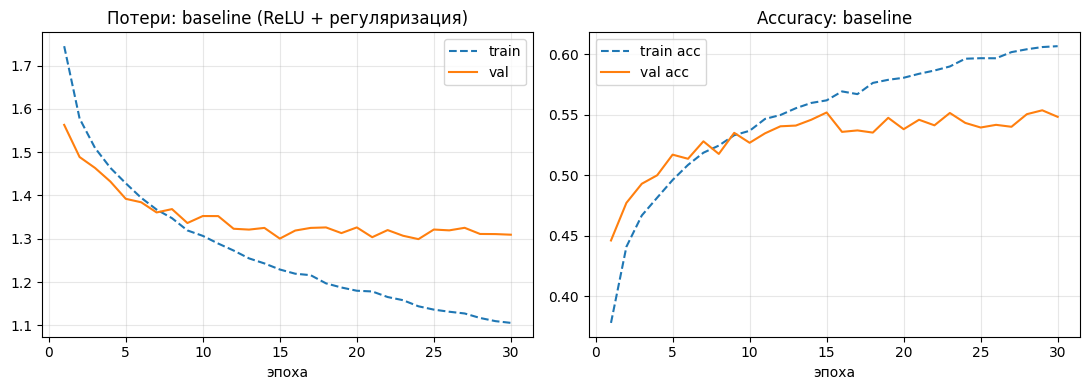

In [6]:
EPOCHS = 30

torch.manual_seed(SEED)
mlp_reg = MLP(dropout_p=0.4, act="relu").to(device)
hist_reg = train_mlp(
    mlp_reg, epochs=EPOCHS, lr=1e-3, weight_decay=1e-4, label="ReLU+рег"
)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, EPOCHS + 1)
ax[0].plot(ep, hist_reg["train_loss"], "--", label="train")
ax[0].plot(ep, hist_reg["val_loss"], label="val")
ax[0].set_title("Потери: baseline (ReLU + регуляризация)")
ax[0].set_xlabel("эпоха")
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(ep, hist_reg["train_acc"], "--", label="train acc")
ax[1].plot(ep, hist_reg["val_acc"], label="val acc")
ax[1].set_title("Accuracy: baseline")
ax[1].set_xlabel("эпоха")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Тот же MLP и ReLU, но регуляризацию выключил

Dropout убрал полностью, weight_decay поставил 0. В следующей ячейке вызывается plot_compare, там на одном рисунке две модели, и loss, и accuracy на val по эпохам.

Без регуляризации train-loss падает гораздо ниже к 30-й эпохе, порядка 0.25 против примерно 1.1 у исходной модели, зато val-loss после середины полез вверх аж до около 3.2, а val accuracy застыл примерно между 0.52 и 0.53 и оказался хуже чем у варианта с регуляризацией. На тесте вышло 0.5126 против 0.5399 у модели с регуляризацией. Это очень похоже на переобучение, сеть всё лучше подгоняет train, но на отложенной части становится хуже


ReLU без рег ep 1/30 train_loss=1.6531 val_loss=1.5301 val_acc=0.4670
ReLU без рег ep 5/30 train_loss=1.1733 val_loss=1.3769 val_acc=0.5380
ReLU без рег ep 10/30 train_loss=0.8205 val_loss=1.5595 val_acc=0.5350
ReLU без рег ep 15/30 train_loss=0.5446 val_loss=1.9093 val_acc=0.5346
ReLU без рег ep 20/30 train_loss=0.3764 val_loss=2.3556 val_acc=0.5274
ReLU без рег ep 25/30 train_loss=0.2880 val_loss=2.8157 val_acc=0.5286
ReLU без рег ep 30/30 train_loss=0.2465 val_loss=3.1968 val_acc=0.5222


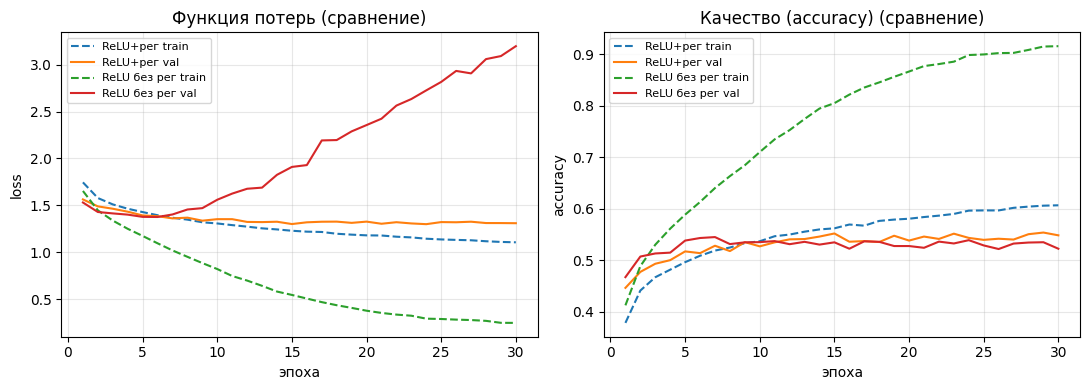

test acc baseline: 0.5399
test acc без регуляризации: 0.5126


In [7]:
torch.manual_seed(SEED)
mlp_noreg = MLP(dropout_p=0.0, act="relu").to(device)
hist_noreg = train_mlp(
    mlp_noreg, epochs=EPOCHS, lr=1e-3, weight_decay=0.0, label="ReLU без рег"
)



plot_compare(
    [hist_reg, hist_noreg],
    ["ReLU+рег", "ReLU без рег"],
    title_suffix=" (сравнение)",
)
print("test acc baseline:", accuracy_loader(mlp_reg, test_loader))
print("test acc без регуляризации:", accuracy_loader(mlp_noreg, test_loader))

## 3. Вместо ReLU поставил sigmoid, регуляризация как у базовой модели

Тот же dropout и тот же weight_decay, поменялась  нелинейность на sigmoid

 на тесте у меня 0.5295 против 0.5399 у ReLU, то есть чуть похуже. У sigmoid выходы зажаты в интервал от нуля до единицы, в насыщенных местах производная мелкая, градиент плохо доходит к нижним слоям, это часто называют проблемой затухающего градиента, плюс обучается всё медленнее. ReLU на положительной полуоси ведёт себя проще и на таких данных обычно удобнее, на кривых видно что train-loss у sigmoid за те же 30 эпох остаётся выше


sigmoid+рег ep 1/30 train_loss=1.8339 val_loss=1.6974 val_acc=0.4076
sigmoid+рег ep 5/30 train_loss=1.5567 val_loss=1.5042 val_acc=0.4802
sigmoid+рег ep 10/30 train_loss=1.4467 val_loss=1.4374 val_acc=0.4932
sigmoid+рег ep 15/30 train_loss=1.3825 val_loss=1.3773 val_acc=0.5220
sigmoid+рег ep 20/30 train_loss=1.3355 val_loss=1.3428 val_acc=0.5290
sigmoid+рег ep 25/30 train_loss=1.2940 val_loss=1.3331 val_acc=0.5318
sigmoid+рег ep 30/30 train_loss=1.2592 val_loss=1.3278 val_acc=0.5352


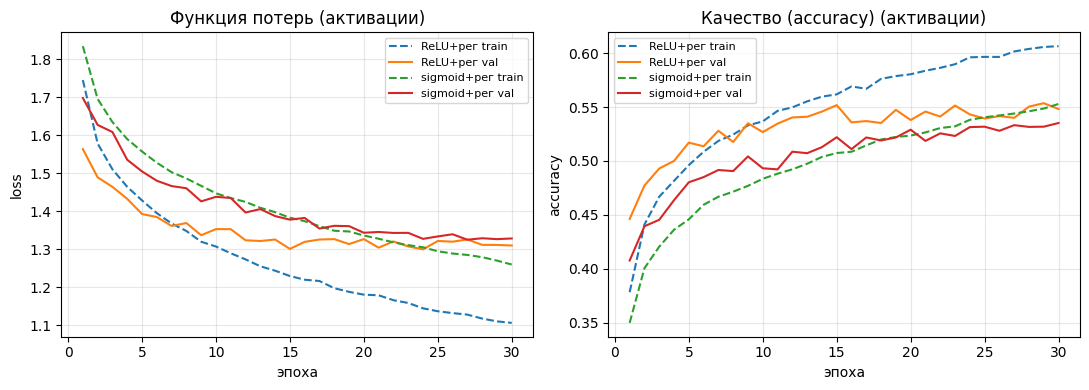

test acc ReLU+рег: 0.5399
test acc sigmoid+рег: 0.5295


In [8]:
torch.manual_seed(SEED)
mlp_sig = MLP(dropout_p=0.4, act="sigmoid").to(device)
hist_sig = train_mlp(
    mlp_sig, epochs=EPOCHS, lr=1e-3, weight_decay=1e-4, label="sigmoid+рег"
)

plot_compare(
    [hist_reg, hist_sig],
    ["ReLU+рег", "sigmoid+рег"],
    title_suffix=" (активации)",
)
print("test acc ReLU+рег:", accuracy_loader(mlp_reg, test_loader))
print("test acc sigmoid+рег:", accuracy_loader(mlp_sig, test_loader))

## 4. Простая CNN

2 блока, в каждом ч conv, потом ReLU, потом max pool, потом один большой линейный слой на карте 64 по каналам и 8 на 8. Веса не переношу из MLP, это отдельное обучение с нуля

 у свёрточной сети на тесте около 0.71, у лучшего MLP с ReLU и регуляризацией примерно 0.54. Тут логично, свёртки смотрят на соседей по картинке и локальные шаблоны, а не на один длинный вектор, для CIFAR-10 отлично подходит


CNN ep 5/20 val_acc=0.6984
CNN ep 10/20 val_acc=0.7234
CNN ep 15/20 val_acc=0.7160
CNN ep 20/20 val_acc=0.7068


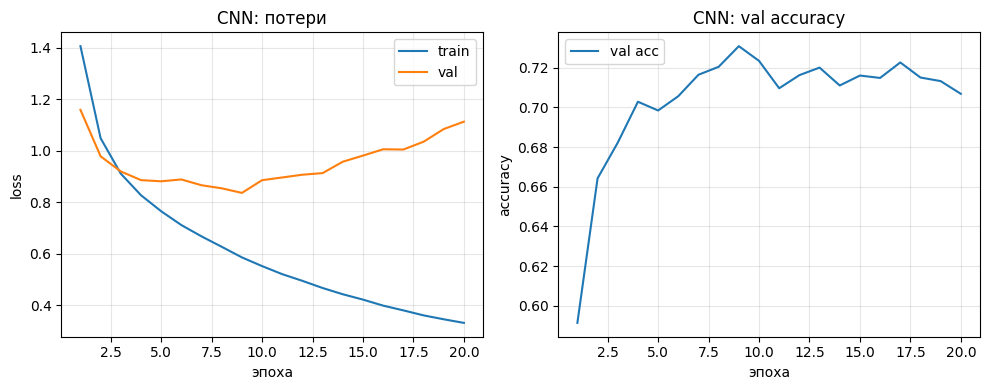

CNN test acc: 0.7108


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        return self.fc(x.view(x.size(0), -1))
def train_cnn(model, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        model.train()
        tl, tn = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            tl += loss.item() * x.size(0)
            tn += x.size(0)
        model.eval()
        vl, va = run_epoch(model, val_loader, opt=None)
        hist["train_loss"].append(tl / tn)
        hist["val_loss"].append(vl)
        hist["val_acc"].append(va)
        if ep % 5 == 0:
            print(f"CNN ep {ep}/{epochs} val_acc={va:.4f}")
    return hist






torch.manual_seed(SEED)
cnn = SimpleCNN().to(device)
EPOCHS_CNN = 20
hist_cnn = train_cnn(cnn, epochs=EPOCHS_CNN, lr=1e-3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS_CNN + 1), hist_cnn["train_loss"], label="train")
plt.plot(range(1, EPOCHS_CNN + 1), hist_cnn["val_loss"], label="val")
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.title("CNN: потери")
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS_CNN + 1), hist_cnn["val_acc"], label="val acc")
plt.xlabel("эпоха")
plt.ylabel("accuracy")
plt.title("CNN: val accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("CNN test acc:", accuracy_loader(cnn, test_loader))

## 5. Активации после первого свёрточного шага

Ниже код берёт немного тестовых картинок и рисует карты после conv1 и ReLU, ещё до pooling, сетка всё ещё 32 на 32.

 по картинкам видно что разные каналы реагируют на разное, где-то всплывают края и контуры объектов или фона, где-то более ровные пятна яркости и цвета. Первый слой по смыслу как раз и учит такие простые локальные штуки, из них дальше уже собираются более сложные признаки.  CNN на этом датасете лучше MLP по точности


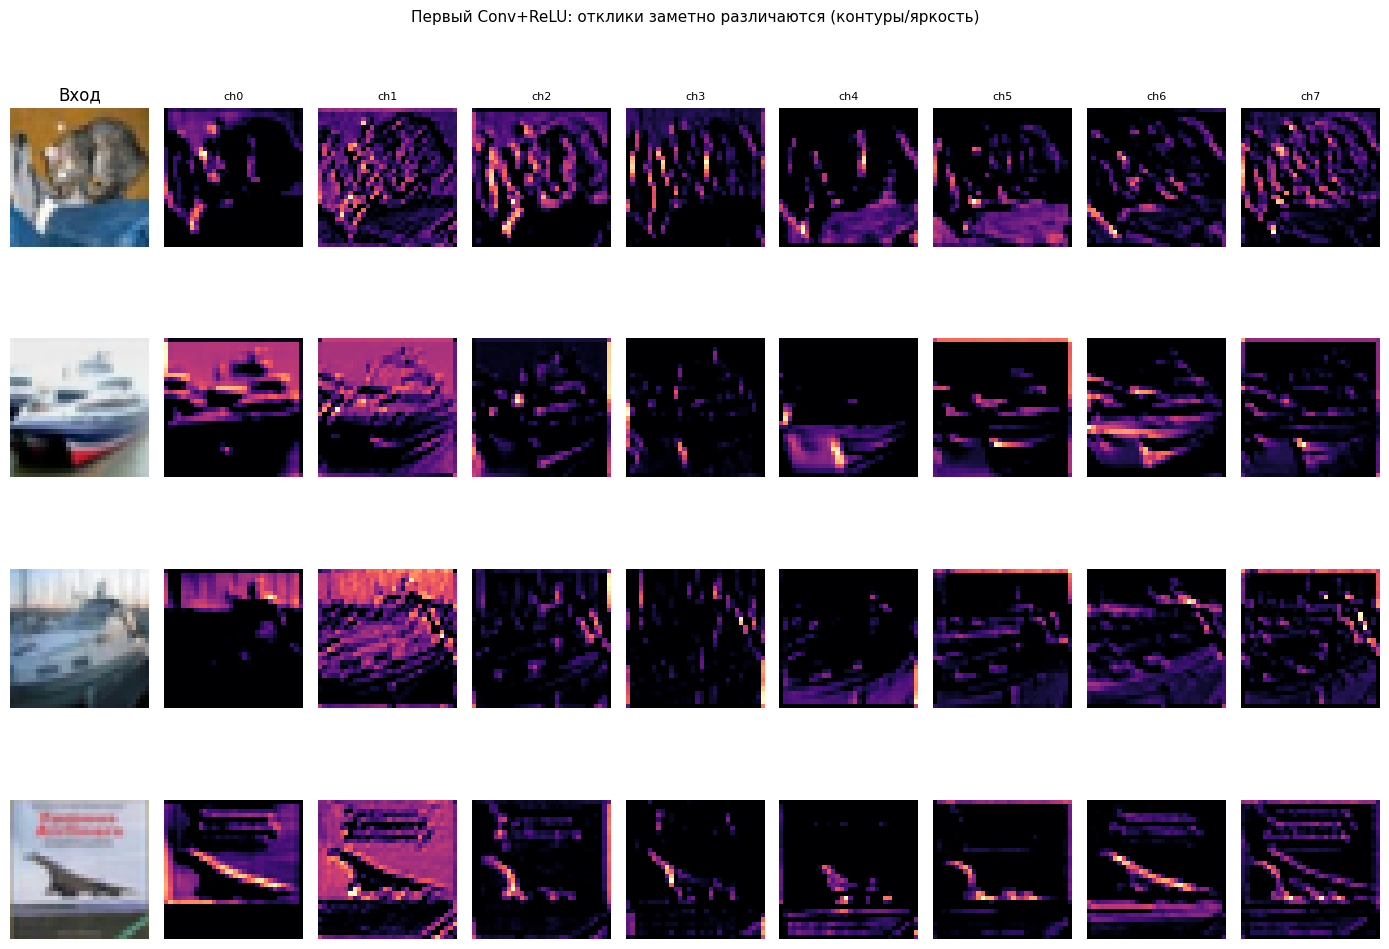

In [10]:
cnn.eval()
with torch.no_grad():
    xb, yb = next(iter(test_loader))
    xb = xb[:4].to(device)
    act = cnn.act1(cnn.conv1(xb))


def denorm_img(t):
    t = t.cpu().clone()
    for i, m, s in zip(range(3), cifar_mean, cifar_std):
        t[i] = t[i] * s + m
    return torch.clamp(t, 0, 1)


n_show, n_maps = 4, 8
fig, axes = plt.subplots(n_show, 1 + n_maps, figsize=(14, 2.6 * n_show))
ch_ids = list(range(min(n_maps, act.size(1))))
for row in range(n_show):
    axes[row, 0].imshow(denorm_img(xb[row]).permute(1, 2, 0).numpy())
    axes[row, 0].axis("off")
    if row == 0:
        axes[row, 0].set_title("Вход")
    maps = act[row].cpu().numpy()
    for k, f in enumerate(ch_ids):
        m = maps[f].copy()
        m = (m - m.min()) / (m.max() - m.min() + 1e-8)
        axes[row, k + 1].imshow(m, cmap="magma")
        axes[row, k + 1].axis("off")
        if row == 0:
            axes[row, k + 1].set_title(f"ch{f}", fontsize=8)
plt.suptitle("Первый Conv+ReLU: отклики заметно различаются (контуры/яркость)", fontsize=11)
plt.tight_layout()
plt.show()